In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import savgol_filter
from scipy.signal import savgol_filter, find_peaks
pd.set_option('display.max_columns', None)

In [7]:
def baseline_correct_sliding_2(signal, window_size=100, percentile=50, anchor=False):
    """
    Remove baseline drift from a 1D signal (already ΔF/F) using a sliding percentile baseline.

    Parameters
    ----------
    signal : 1D array-like
        ΔF/F data (frames,).
    window_size : int
        Number of frames to look back and ahead for the baseline.
    percentile : float
        Percentile to use for baseline (low percentile avoids transients).
    anchor : bool
        If True, shift the baseline so that baseline[0] = 0 (keeps first point fixed).

    Returns
    -------
    corrected : np.ndarray
        Baseline-corrected ΔF/F signal.
    baseline : np.ndarray
        The sliding baseline used.
    """
    signal = np.asarray(signal).flatten()
    n_frames = len(signal)
    F0_sliding = np.empty_like(signal)

    for frame in range(n_frames):
        start = max(0, frame - window_size)
        end   = min(n_frames, frame + window_size)
        F0_sliding[frame] = np.nanpercentile(signal[start:end], percentile)

    if anchor:
        F0_sliding = F0_sliding - F0_sliding[0]

    corrected = signal - F0_sliding
    return corrected, F0_sliding


In [8]:
def detect_events_1d(trace, filter_window=9, filter_polyorder=2, 
                     start_frame=1, end_frame=-1,
                     percentile=30, height=3, prominence=6.5,
                     min_distance=1, min_duration=20, min_auc=15, 
                     exclude_frames=None, linewidth=1.25, plot=True, title=None,
                     local_halfwidth=100):
    """
    Detect spontaneous events in a single ΔF/F₀ trace.

    local_halfwidth : int
        Number of frames before and after the peak used to compute the local percentile.
        (local window size = 2*local_halfwidth + 1). Default 50 (i.e. 101-frame window).
    """
    # set default exclusion if none provided
    if exclude_frames is None:
        exclude_frames = [(430,1000)]
    
    # Smooth trace
    if filter_window % 2 == 0:
        filter_window += 1
    smoothed_trace = savgol_filter(trace, window_length=int(filter_window), polyorder=filter_polyorder)

    # Mask excluded frames
    mask = np.ones_like(smoothed_trace, dtype=bool)
    if exclude_frames is not None:
        for (s, e) in exclude_frames:
            # guard indices
            s = max(0, int(s))
            e = min(len(mask), int(e))
            mask[s:e] = False

    # Noise estimate (MAD scaled to std) using valid (non-excluded) data
    valid_trace = smoothed_trace[mask]
    mad = np.median(np.abs(valid_trace - np.median(valid_trace))) + 1e-12
    sigma = 1.4826 * mad
    # global percentile (fallback)
    global_perc_thr = np.percentile(valid_trace, percentile)

    # Restrict detection region
    detect_mask = mask.copy()
    detect_mask[:start_frame] = False
    if end_frame != -1:
        ef = end_frame if end_frame >= 0 else len(smoothed_trace) + end_frame
        ef = max(0, min(len(smoothed_trace), ef))
        detect_mask[ef:] = False

    candidate_indices = np.where(detect_mask)[0]
    candidate_signal  = smoothed_trace[detect_mask]

    # Find peaks
    peaks_local, _ = find_peaks(
        candidate_signal,
        height=height * sigma,
        prominence=prominence * sigma,
        distance=min_distance
    )
    peaks = candidate_indices[peaks_local]

    # Build event dicts
    events = []
    for pk in peaks:
        # compute local percentile threshold around the peak
        s_idx = max(0, int(pk - local_halfwidth))
        e_idx = min(len(smoothed_trace), int(pk + local_halfwidth) + 1)  # slice end-exclusive
        local_segment = smoothed_trace[s_idx:e_idx]
        local_mask = detect_mask[s_idx:e_idx]

        # only consider frames that are within detection region (i.e., not excluded)
        if np.any(local_mask):
            local_vals = local_segment[local_mask]
            # if there are too few local vals, fallback to global
            if local_vals.size >= 3:
                perc_thr = np.percentile(local_vals, percentile)
            else:
                perc_thr = global_perc_thr
        else:
            perc_thr = global_perc_thr

        # Expand start/end using local percentile
        start = pk
        while start > 0 and smoothed_trace[start-1] > perc_thr and detect_mask[start-1]:
            start -= 1
        end = pk
        while end < len(smoothed_trace)-1 and smoothed_trace[end+1] > perc_thr and detect_mask[end+1]:
            end += 1
        duration = end - start + 1
        duration_ms = (duration * 1000) / 599.52
        
        if duration >= min_duration:
            # Compute AUC using trapezoidal integration
            event_segment = smoothed_trace[start:end+1]
            event_segment = smoothed_trace[start:end+1]
            auc = np.trapz(event_segment - perc_thr) ## NEW code for 4th run
            # auc = np.trapz(event_segment) ## Code for 3rd run

            if auc >= min_auc:
                events.append({
                    "Start": int(start),
                    "End": int(end),
                    "Duration": int(duration_ms),
                    "Frame Peak": int(pk),
                    "AUC": float(auc)   # <-- store AUC
                })

        else:
            continue

    # Optional plot
    if plot:
        plt.figure(figsize=(12, 4))
        plt.plot(smoothed_trace, color='#6180B4', linewidth=linewidth, label='Smoothed ΔF/F₀')
        for idx, ev in enumerate(events, start=1):
            # highlight event span
            plt.axvspan(ev["Start"], ev["End"], color='indianred', alpha=0.3)
            plt.axvline(ev["Frame Peak"], color='red', linestyle='--', alpha=0.7)
            # add event number above the peak
            peak_val = smoothed_trace[ev["Frame Peak"]]
            plt.text(ev["Frame Peak"], peak_val,
             f'{ev["Duration"]} ms\nAUC {ev["AUC"]:.2f}',
             ha='center', va='bottom',
             fontsize=12, fontweight='bold', color='C0')


        # plot a representative global percentile threshold and height threshold
        plt.axhline(global_perc_thr, color='green', linestyle='--', label=f'Global {percentile}th Percentile')
        plt.axhline(height * sigma, color='gray', linestyle='--', label='Height Threshold')
        if exclude_frames is not None and len(exclude_frames):
            for (s,e) in exclude_frames:
                plt.axvspan(s, e, color='black', alpha=0.15, label='Excluded')
        if title:
            plt.title(title)
        plt.xlabel("Frame"); plt.ylabel("ΔF/F₀")
        plt.legend(); plt.tight_layout(); plt.show()

    return pd.DataFrame(events)


In [9]:
dataDir = ' ' # 'Data_folder'
slice = pd.read_csv(dataDir+' ', delimiter=',', header=[0,1]) # 'Slice_data.csv'
slice_traces = slice.iloc[:, 0:15]
# slice_traces = slice.iloc[:, 20:] 
slice_traces.head(0)

Empty DataFrame
Columns: [(Control, 1p), (Control, 1p.1), (Control, 1p.2), (Control, 1p.3), (Control, 1p.4), (Control, 1p.5), (Control, 1p.6), (Control, 1p.7), (Control, 4p 100 Hz), (Control, 2p 100 Hz), (Control, 3p 100 Hz), (Control, 1p x), (Control, 3p 100 Hz.1), (Control, 4p 100 Hz.1), (Control, 2p 100 Hz.1)]
Index: []

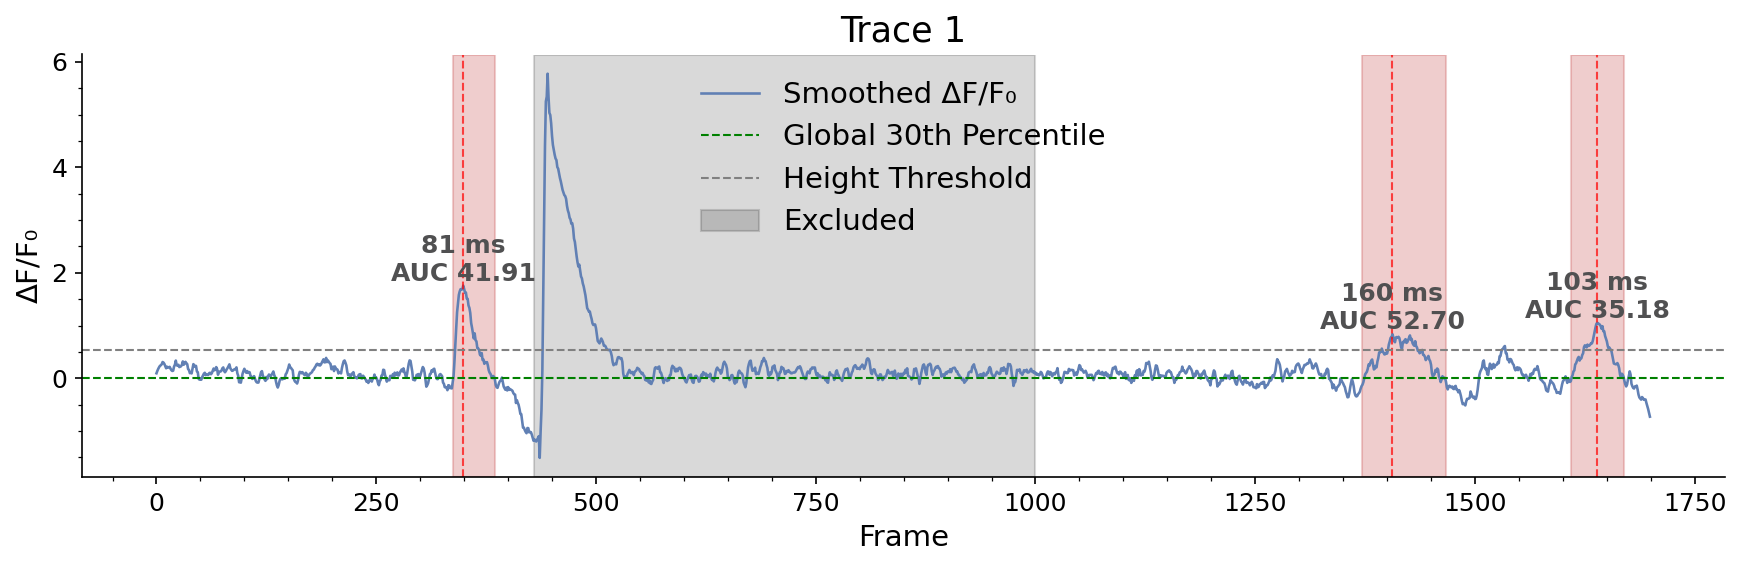

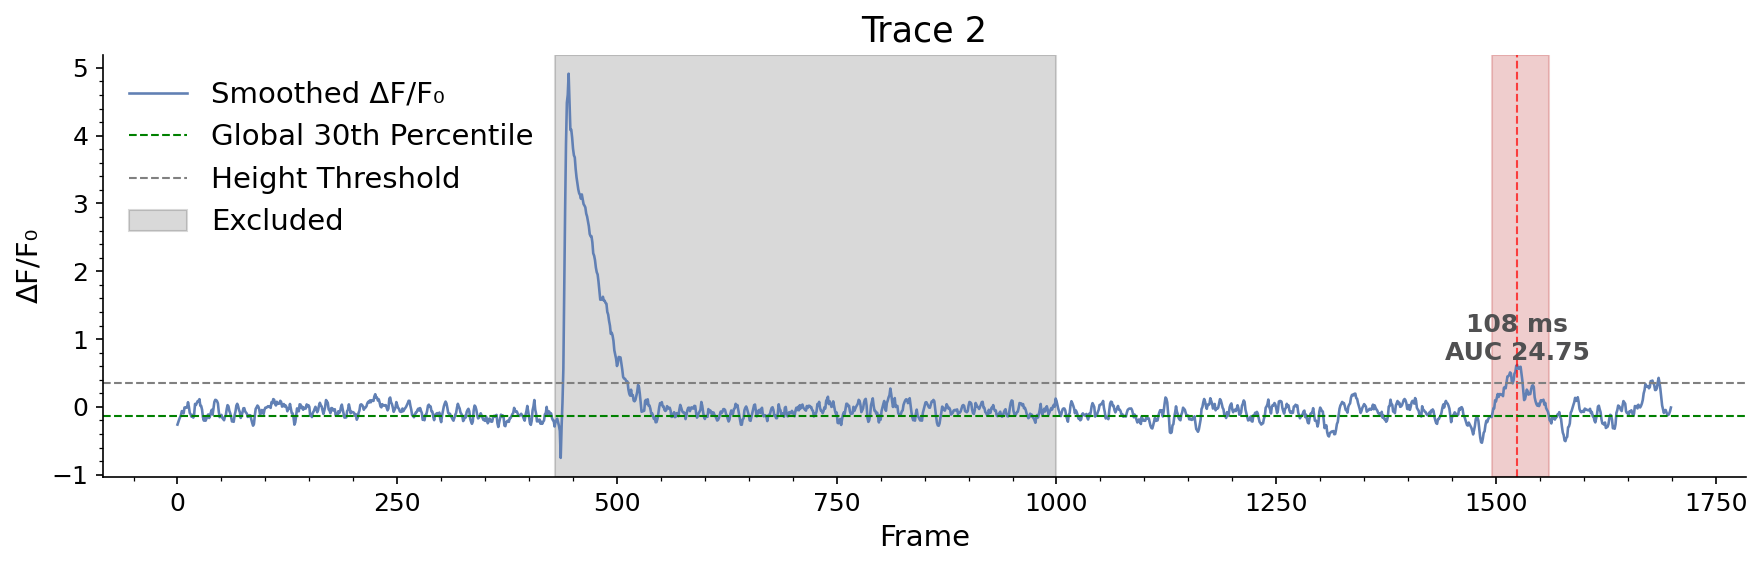

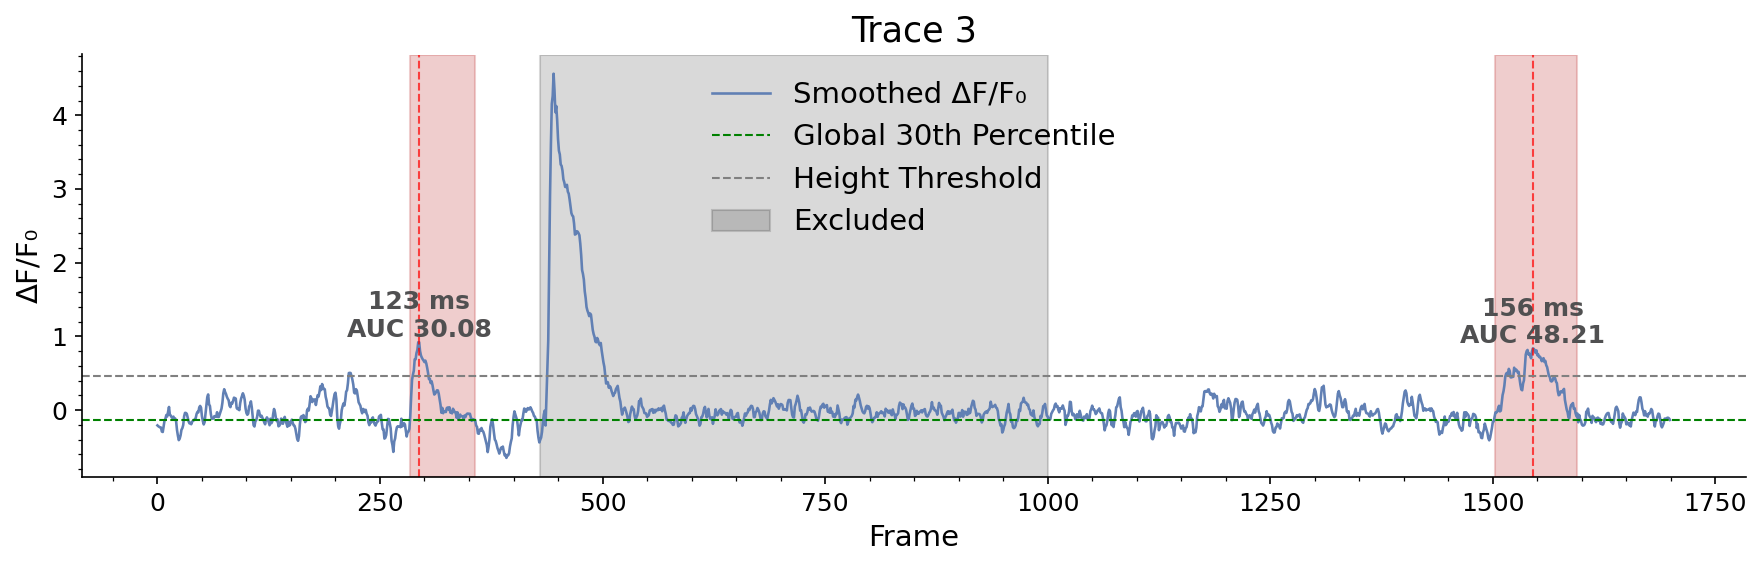

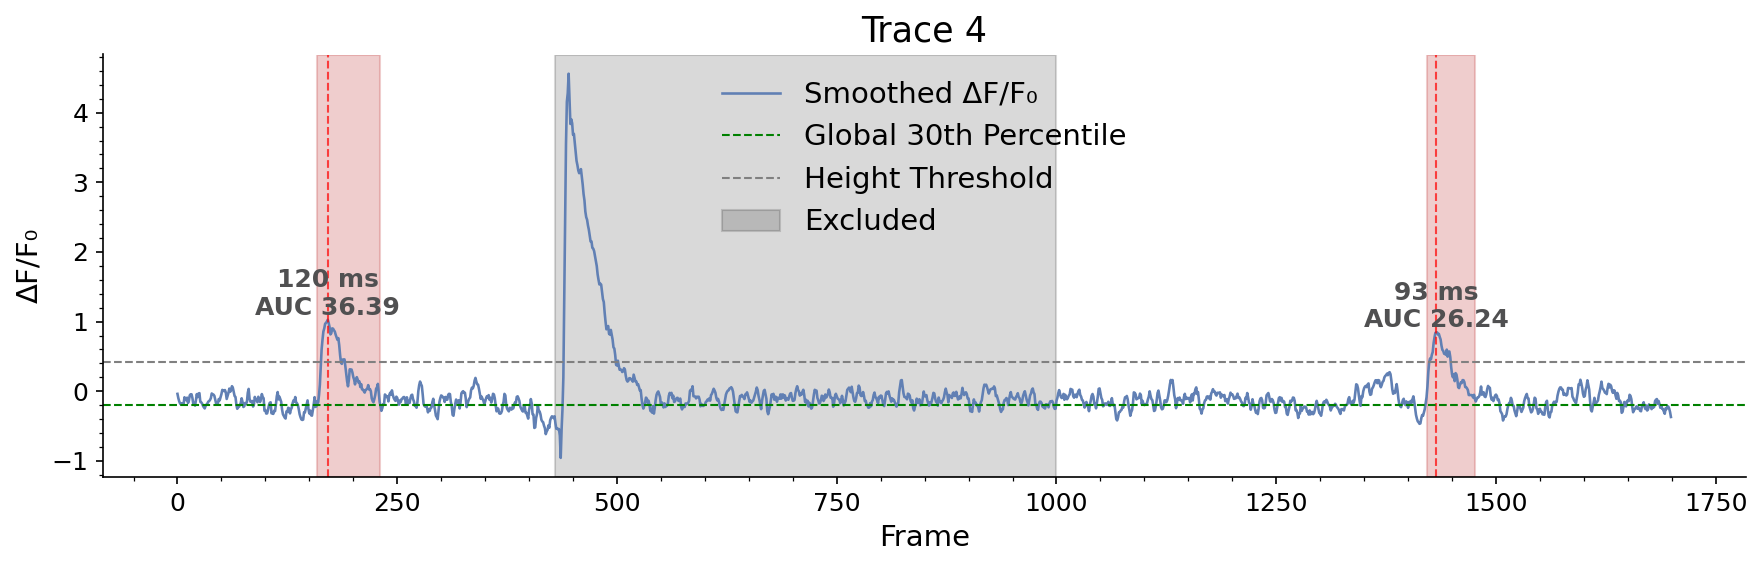

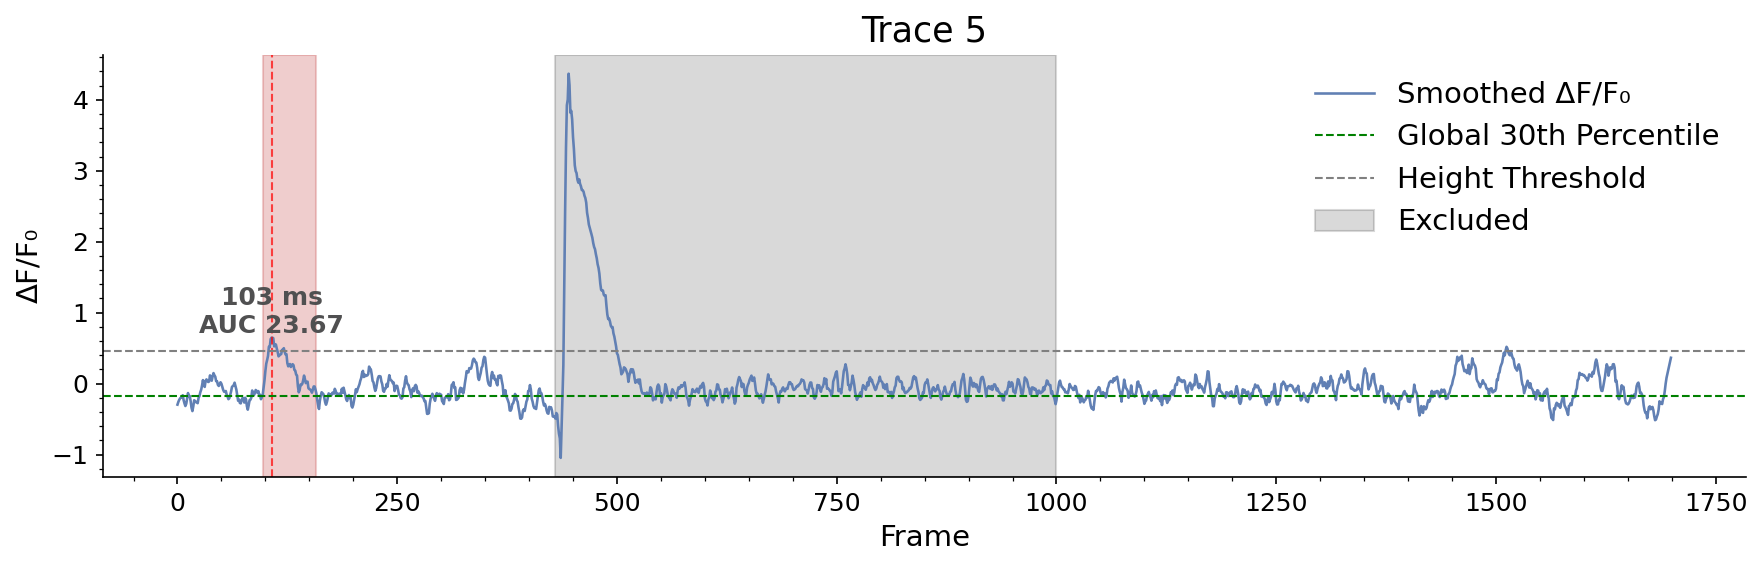

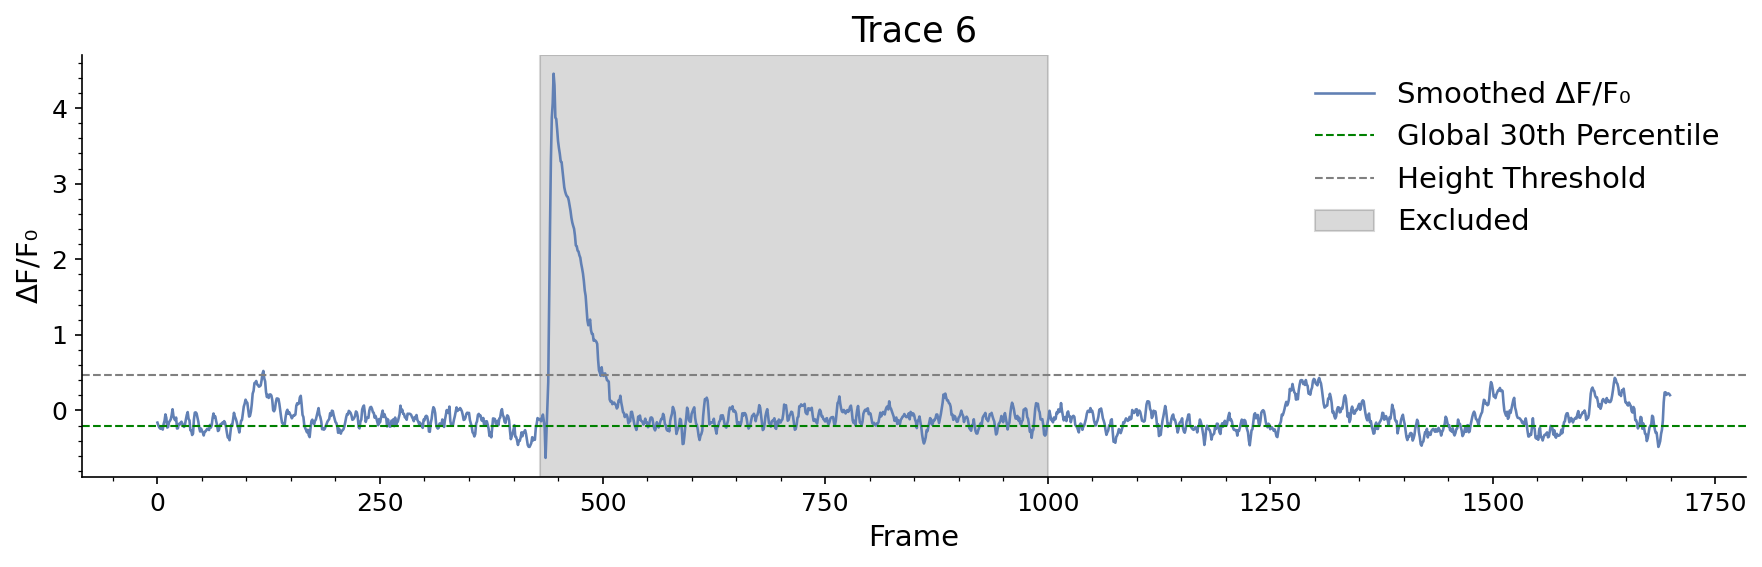

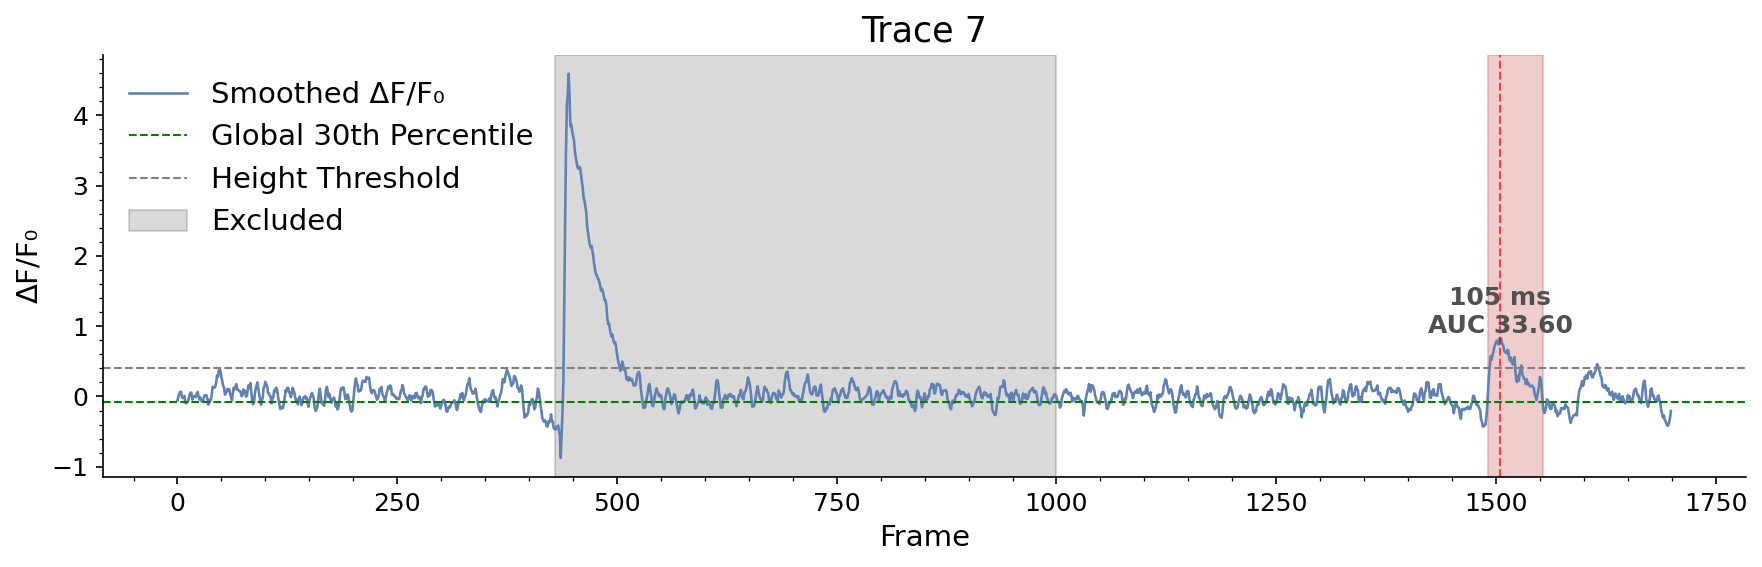

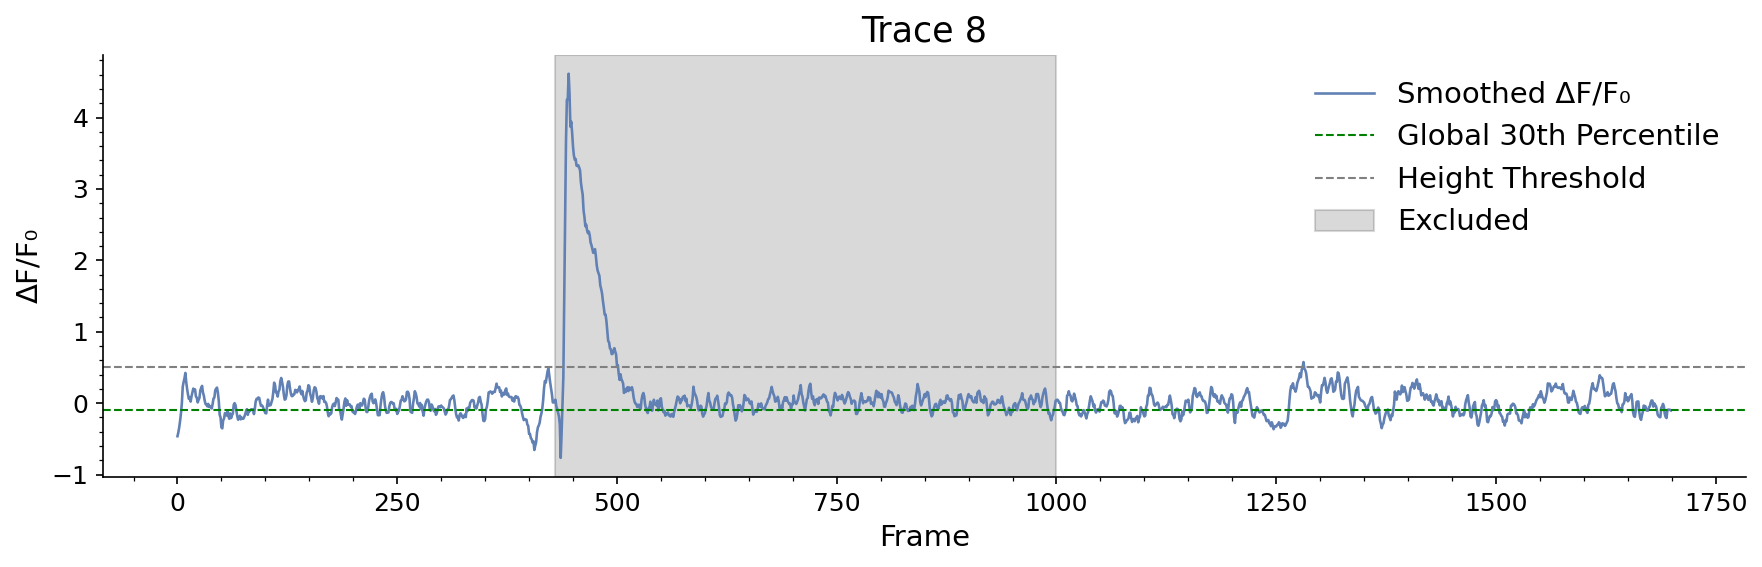

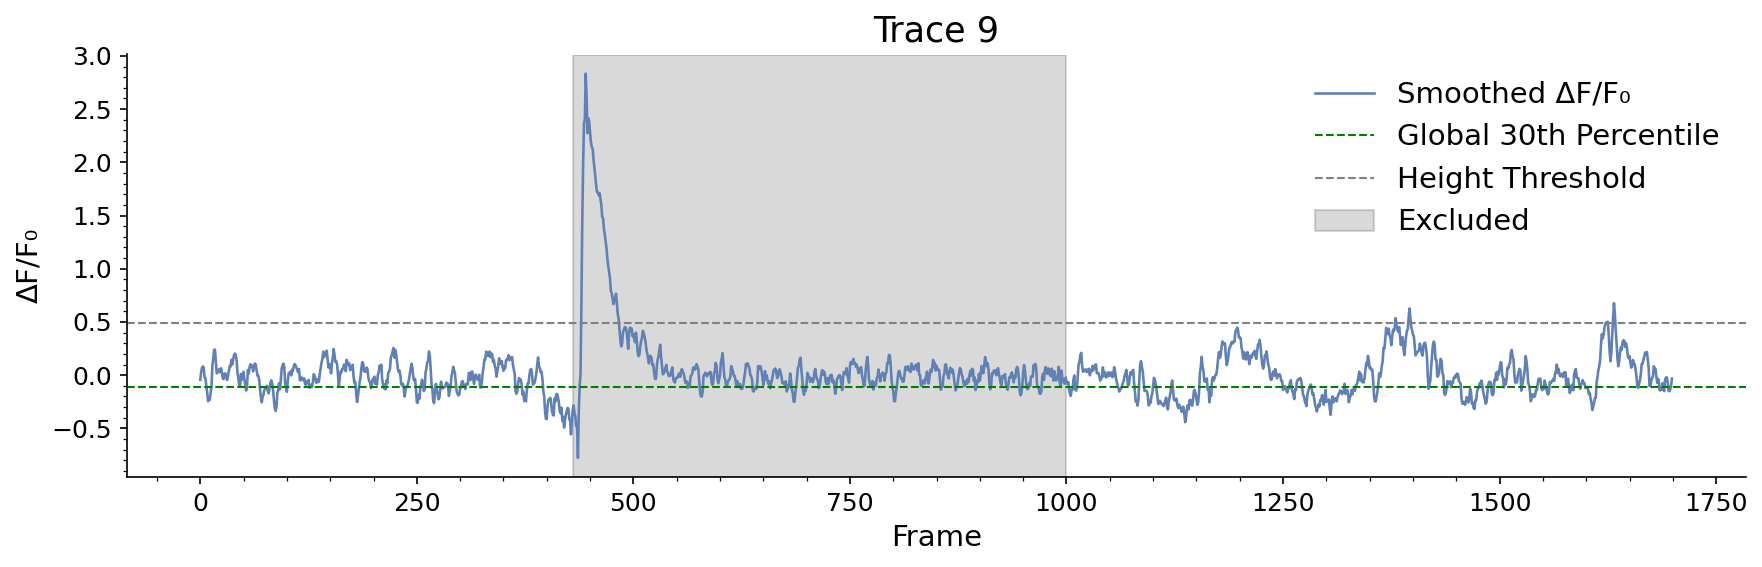

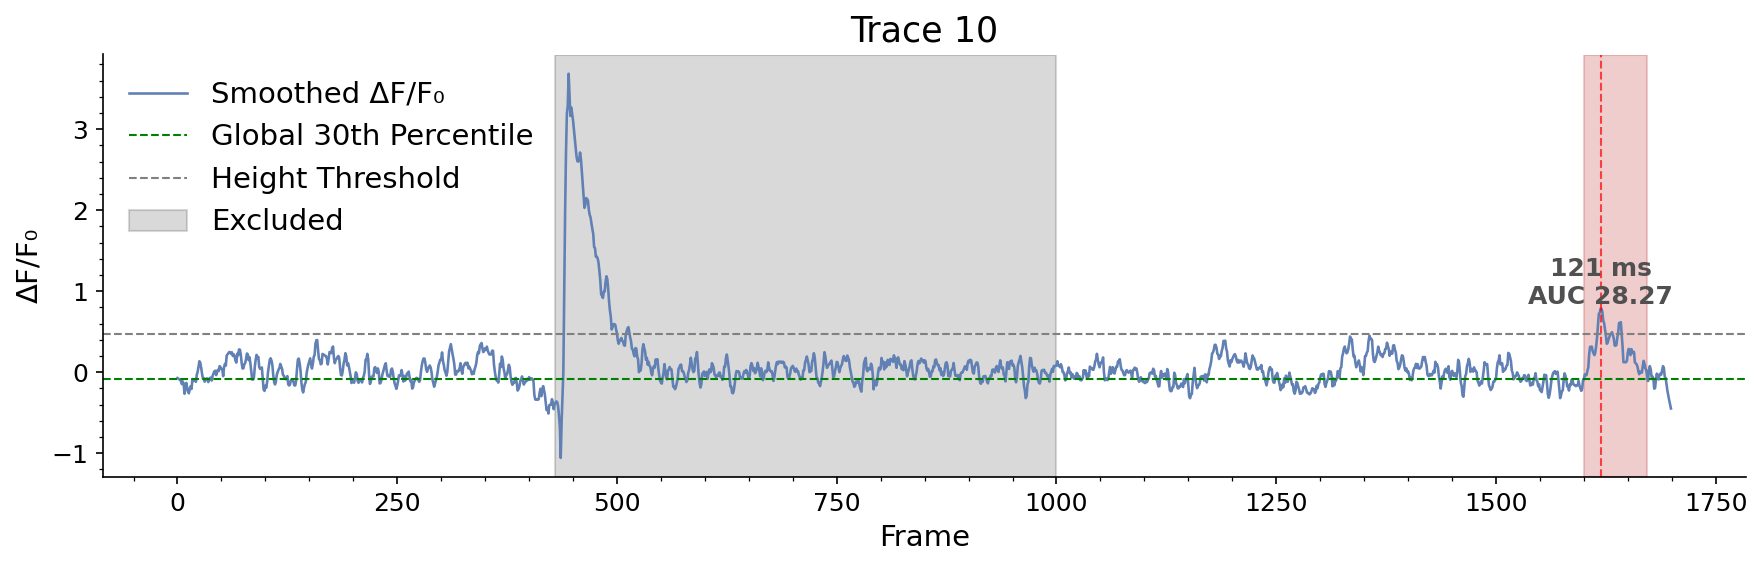

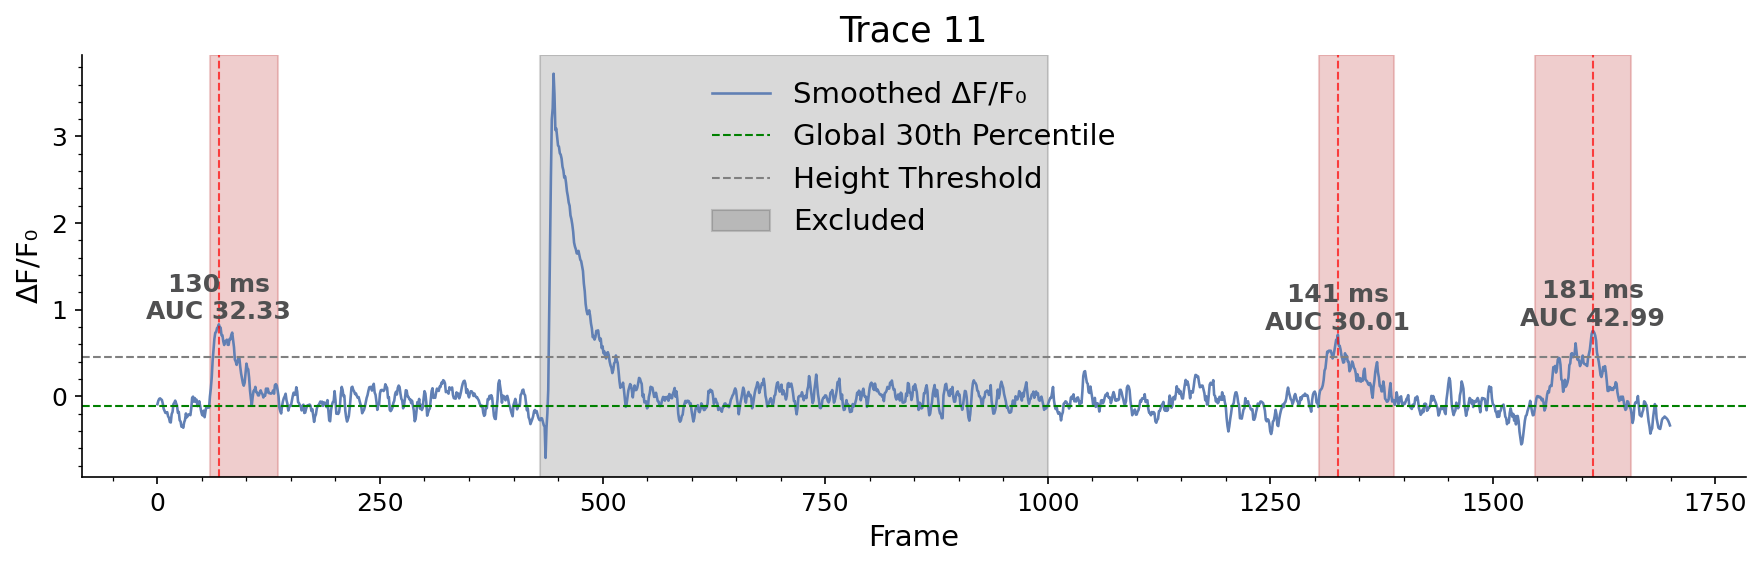

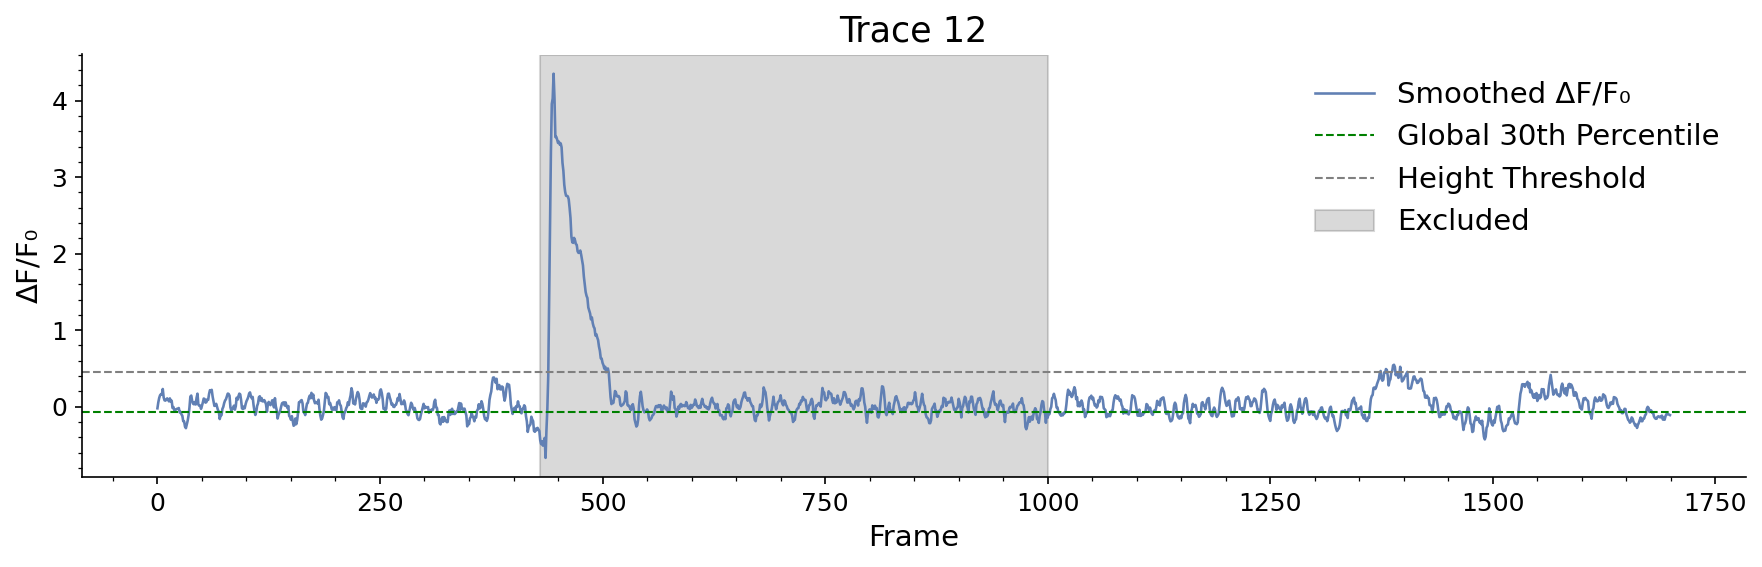

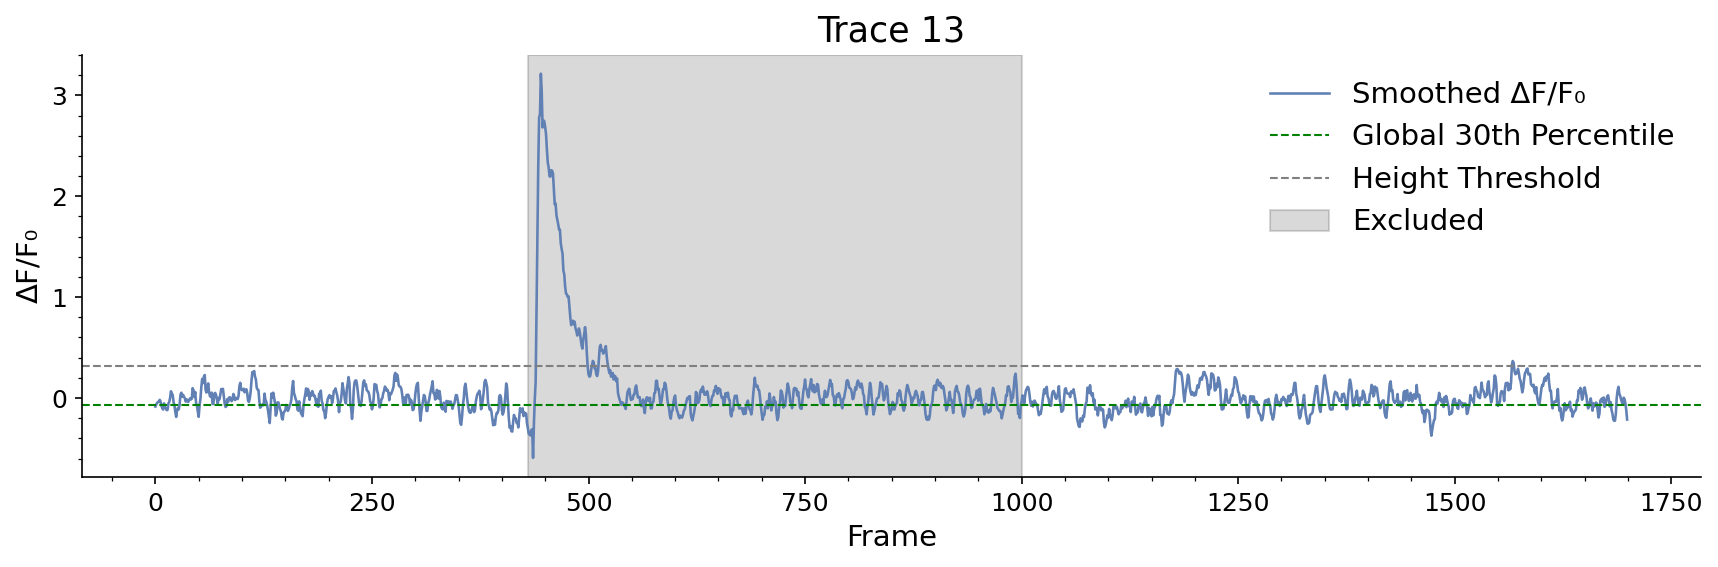

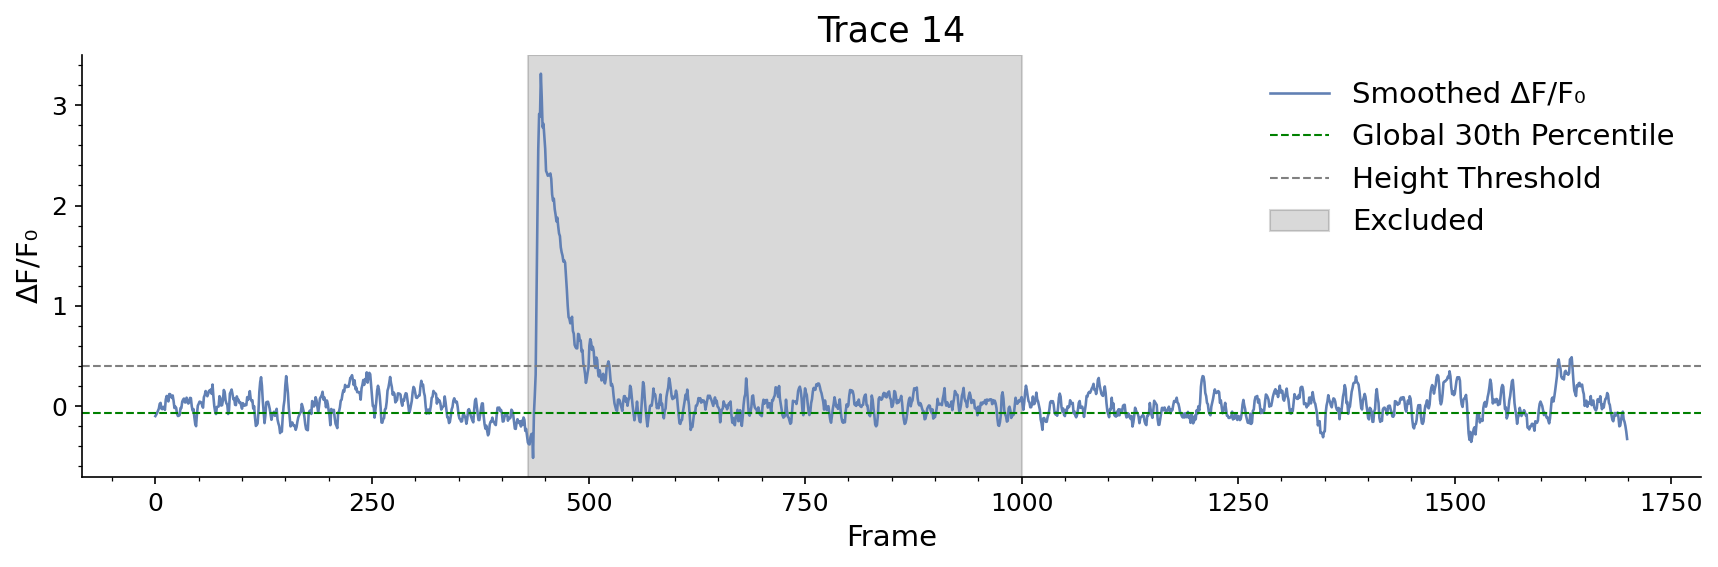

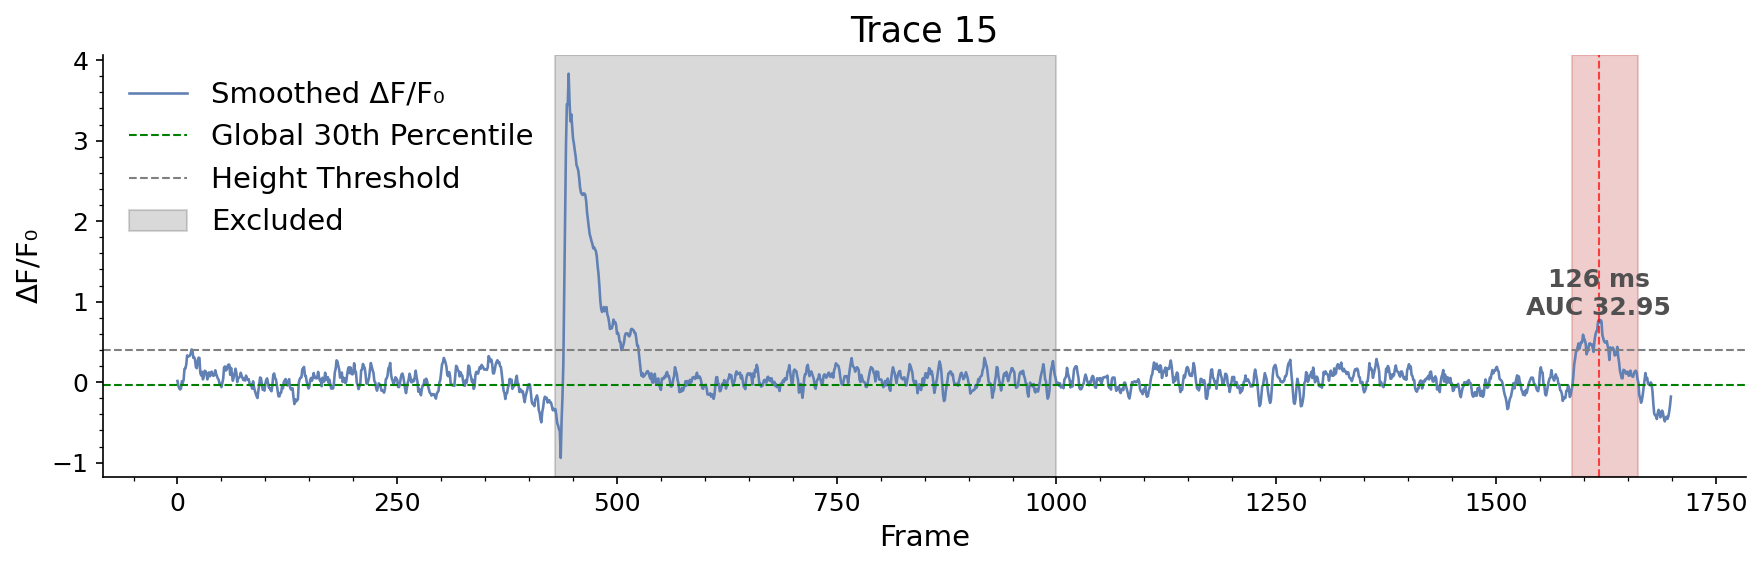

In [10]:
%matplotlib inline
for i in range(slice_traces.shape[1]):
    signal = slice_traces.iloc[400:, i:i+1]
    corrected, baseline = baseline_correct_sliding_2(signal, window_size=100, anchor=True)
    trace = np.asarray(corrected).ravel()
    detect_events_1d(trace, title=f"Trace {i+1}")

In [11]:
### DLS ###
stimuli = ['1p']*7 + ['4p (100Hz)', '2p (100Hz)', '3p (100Hz)', '1p', '3p (100Hz)', '4p (100Hz)', '2p (100Hz)', '1p', '2p (100Hz)', '3p (100Hz)', '4p (100Hz)', '1p']  #240111
# stimuli = ['1p']*8 + ['4p (50Hz)', '4p (100Hz)', '1p', '4p (100Hz)', '1p', '4p (50Hz)', '4p (100Hz)', '4p (50Hz)', '1p']  #240206
# stimuli = ['1p']*8 + ['4p (100Hz)', '1p', '4p (50Hz)', '4p (100Hz)', '4p (50Hz)', '1p', '4p (50Hz)', '4p (50Hz)', '4p (100Hz)', '1p']  # 240207
# stimuli = ['1p']*8 + ['4p (100Hz)', '4p (50Hz)', '1p', '4p (50Hz)', '4p (100Hz)', '1p', '4p (50Hz)', '4p (100Hz)', '1p']  # 240209
# stimuli = ['1p']*8 + ['4p (100Hz)', '4p (50Hz)', '1p', '4p (50Hz)', '4p (100Hz)', '1p', '4p (100Hz)', '4p (50Hz)', '1p'] # 240523
# stimuli = ['1p']*11 + ['4p (50Hz)', '4p (100Hz)', '1p', '4p (100Hz)', '4p (50Hz)', '1p', '4p (50Hz)', '4p (100Hz)' , '1p'] # 240607
# stimuli = ['1p']*7 + ['4p (50Hz)', '4p (100Hz)', '1p', '4p (100Hz)', '4p (50Hz)', '1p', '4p (50Hz)', '4p (100Hz)', '1p'] # 240219
# stimuli = ['1p']*8 + ['4p (50Hz)', '4p (100Hz)', '1p', '4p (100Hz)', '4p (50Hz)', '1p', '4p (50Hz)', '4p (100Hz)', '1p'] # 240412
# stimuli = ['1p']*8 + ['4p (100Hz)', '4p (50Hz)', '1p', '4p (50Hz)', '4p (100Hz)', '1p', '4p (100Hz)', '4p (50Hz)', '1p'] # 240415
# stimuli = ['1p']*8 + ['4p (50Hz)', '4p (100Hz)', '1p', '4p (100Hz)', '4p (50Hz)', '1p', '4p (50Hz)', '4p (100Hz)', '1p'] # 240521
# stimuli = ['1p']*8 + ['2p (100Hz)', '3p (100Hz)', '4p (100Hz)', '1p', '4p (100Hz)', '2p (100Hz)', '3p (100Hz)', '1p', '3p (100Hz)', '4p (100Hz)', '2p (100Hz)', '1p'] # 241022_slice5
# stimuli = ['1p']*8 + ['4p (100Hz)', '3p (100Hz)', '2p (100Hz)', '1p', '3p (100Hz)', '2p (100Hz)', '4p (100Hz)', '1p', '2p (100Hz)', '4p (100Hz)', '3p (100Hz)', '1p'] # 241022_slice6
# stimuli = ['1p']*8 + ['4p (100Hz)', '1p', '4p (100Hz)', '1p', '4p (100Hz)', '1p'] # my data

all_events = []

for i in range(slice_traces.shape[1]):
    signal = slice_traces.iloc[400:, i].to_numpy()
    corrected, baseline = baseline_correct_sliding_2(signal, window_size=100, anchor=True)
    trace = np.asarray(corrected).ravel()
    events = detect_events_1d(trace, plot=False)

    # turn list of dicts into DataFrame
    df_events = pd.DataFrame(events)
    df_events["Trace"] = i+1   # tag which stim/channel/column this came from
    df_events["Stim"] = stimuli[i]
    all_events.append(df_events)

# concatenate into one big dataframe
events_df = pd.concat(all_events, ignore_index=True)

# move Trace and Stim to the front
cols = ["Trace", "Stim"] + [c for c in events_df.columns if c not in ("Trace", "Stim")]
events_df = events_df[cols]

events_df

,Trace,Stim,Start,End,Duration,Frame Peak,AUC
0,1,1p,337.0,385.0,81.0,349.0,41.910192
1,1,1p,1372.0,1467.0,160.0,1406.0,52.696975
2,1,1p,1609.0,1670.0,103.0,1639.0,35.178713
3,2,1p,1496.0,1560.0,108.0,1524.0,24.745744
4,3,1p,284.0,357.0,123.0,294.0,30.075822
5,3,1p,1502.0,1595.0,156.0,1545.0,48.209418
6,4,1p,159.0,230.0,120.0,171.0,36.389735
7,4,1p,1421.0,1476.0,93.0,1432.0,26.235593
8,5,1p,97.0,158.0,103.0,107.0,23.667845
9,7,1p,1491.0,1553.0,105.0,1505.0,33.600497


In [13]:
# prime_events = events_df.drop([10]).reset_index(drop=True)
prime_events = events_df
prime_events

,Trace,Stim,Start,End,Duration,Frame Peak,AUC
0,1,1p,337.0,385.0,81.0,349.0,41.910192
1,1,1p,1372.0,1467.0,160.0,1406.0,52.696975
2,1,1p,1609.0,1670.0,103.0,1639.0,35.178713
3,2,1p,1496.0,1560.0,108.0,1524.0,24.745744
4,3,1p,284.0,357.0,123.0,294.0,30.075822
5,3,1p,1502.0,1595.0,156.0,1545.0,48.209418
6,4,1p,159.0,230.0,120.0,171.0,36.389735
7,4,1p,1421.0,1476.0,93.0,1432.0,26.235593
8,5,1p,97.0,158.0,103.0,107.0,23.667845
9,7,1p,1491.0,1553.0,105.0,1505.0,33.600497


Processed event 0: peak=1.6977, rise=20.0 ms, half_life=18.348011742727515 ms
Processed event 1: peak=0.8884, rise=56.7 ms, half_life=73.39204697091006 ms
Processed event 2: peak=0.9218, rise=50.0 ms, half_life=21.684013877768884 ms
Processed event 3: peak=1.1759, rise=46.7 ms, half_life=58.38003736322391 ms
Processed event 4: peak=0.8612, rise=16.7 ms, half_life=18.348011742727515 ms
Processed event 5: peak=1.0925, rise=71.7 ms, half_life=46.70402989057913 ms
Processed event 6: peak=1.2907, rise=20.0 ms, half_life=33.36002135041367 ms
Processed event 7: peak=1.0542, rise=18.3 ms, half_life=30.0240192153723 ms
Processed event 8: peak=0.7755, rise=18.3 ms, half_life=35.028022417934345 ms
Processed event 9: peak=1.0050, rise=23.4 ms, half_life=30.0240192153723 ms
Processed event 10: peak=0.9626, rise=31.7 ms, half_life=43.36802775553777 ms
Processed event 11: peak=1.0364, rise=16.7 ms, half_life=41.70002668801708 ms
Processed event 12: peak=0.9000, rise=35.0 ms, half_life=35.028022417934

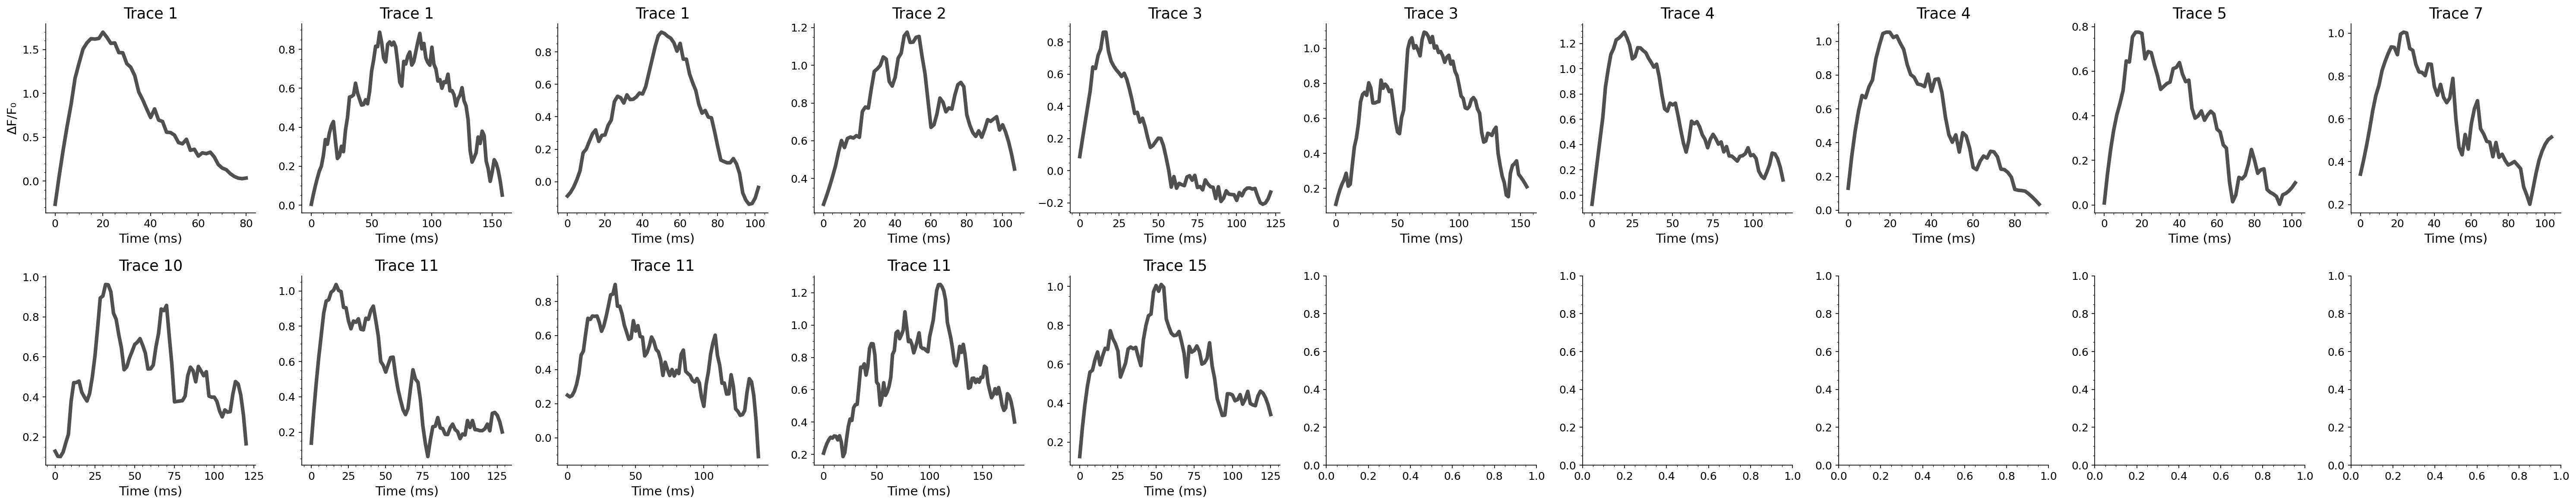

In [14]:
def baseline_correct(dff, frame_start, frame_end, framesBefore=100, framesAfter=10):
    """
    Return baseline-corrected segment corresponding to [frame_start, frame_end] inclusive.
    Handles edges by clipping to available samples.
    """
    n = len(dff)
    s = max(0, int(frame_start - framesBefore))
    e = min(n, int(frame_end + framesAfter) + 1)  # +1 because slice end is exclusive
    parsed = dff[s:e]

    # if parsed is shorter than expected (near edges), adjust framesBefore accordingly
    actual_frames_before = min(framesBefore, int(frame_start - s))
    if actual_frames_before <= 0:
        # fallback: use mean of first few samples
        baseline = np.mean(parsed[:max(1, min(10, len(parsed)))])
    else:
        baseline = np.mean(parsed[:actual_frames_before])

    corrected = parsed - baseline

    # number of frames in requested inclusive window
    desired_len = int(frame_end - frame_start + 1)
    start_idx = actual_frames_before
    end_idx = start_idx + desired_len
    # Clip end_idx to available length
    corrected_segment = corrected[start_idx:end_idx]
    return corrected_segment


fps = 599.52
trace_start = 400  # was 400

%matplotlib inline
aucs = []
peaks = []
rise_times = []
half_lives = []
durations = []

n_events = prime_events.shape[0]
# Ensure axes is always an array for consistent indexing
# ---- Dynamic subplot grid (max 10 per row) ----
max_cols = 10
n_cols = min(n_events, max_cols)
n_rows = int(np.ceil(n_events / max_cols))

fig, ax_arr = plt.subplots(n_rows, n_cols,
                           figsize=(4 * n_cols, 4 * n_rows))

# Ensure ax_arr is always flat for easy indexing
ax_arr = np.atleast_1d(ax_arr).flatten()

for i in range(n_events):
    trace_no = int(prime_events['Trace'][i])
    start_parse, end_parse = int(prime_events['Start'][i]), int(prime_events['End'][i])
    trace = slice.iloc[:, trace_no -1].to_numpy() #### If 'Time' column is NOT in slice_traces
    # trace = slice.iloc[:, trace_no].to_numpy() #### If 'Time' column is in slice_traces

    # baseline correct and smooth
    seg = baseline_correct(trace, trace_start + start_parse, trace_start + end_parse,
                           framesBefore=100, framesAfter=10)
    if len(seg) == 0:
        print(f"Event {i}: empty segment after baseline correction — skipping")
        aucs.append(np.nan); peaks.append(np.nan); rise_times.append(np.nan)
        half_lives.append(np.nan); durations.append(np.nan)
        continue

    sg = savgol_filter(seg, window_length=9 if len(seg) >= 9 else (len(seg)//2*2+1), polyorder=2)
    time_ms = np.arange(len(sg)) * 1000.0 / fps

    ax = ax_arr[i]
    ax.plot(time_ms, sg, '-', linewidth=4, color='C0')
    ax.set(title=f'Trace {trace_no}', xlabel="Time (ms)")
    if i == 0:
        ax.set(ylabel="ΔF/F₀")

    # metrics
    aucs.append(np.trapz(sg, dx=1000.0/fps))
    peak_idx = int(np.argmax(sg))
    peak_val = float(sg[peak_idx])
    peaks.append(peak_val)
    rise_times.append(time_ms[peak_idx])  # time from segment start to peak (ms)
    durations.append((len(sg) / fps) * 1000.0)

    # compute half-life robustly: time from peak to first sample <= half max
    half_level = peak_val / 2.0
    tail = sg[peak_idx:]  # includes the peak sample
    below_idx = np.where(tail <= half_level)[0]
    if below_idx.size == 0:
        # no crossing found — define behavior: set NaN (or use time to end)
        half_life_ms = np.nan
        # alternative: uncomment to use time to end as a lower bound:
        # half_life_ms = (len(sg) - 1 - peak_idx) / fps * 1000.0
        print(f"Event {i}: no half-peak crossing after peak (peak={peak_val:.3f})")
    else:
        crossing_idx = below_idx[0] + peak_idx
        half_life_ms = (crossing_idx - peak_idx) / fps * 1000.0  # ms from peak to half
    half_lives.append(half_life_ms)

    print(f"Processed event {i}: peak={peak_val:.4f}, rise={rise_times[-1]:.1f} ms, half_life={half_lives[-1]} ms")

plt.tight_layout()
plt.show()


In [18]:
df_to_plot = pd.DataFrame({
    'Time (ms)':time_ms,
    'F/F':sg
})

df_to_plot.to_csv(dataDir + ' ', index=None) # 'Output_file_name.csv'